In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Create .kaggle directory
!mkdir -p ~/.kaggle

# Upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Move kaggle.json to the right location
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API configured successfully!


In [ ]:
# Download the fingerprint blood group dataset
!kaggle datasets download -d rajumavinmar/finger-print-based-blood-group-dataset

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/rajumavinmar/finger-print-based-blood-group-dataset
License(s): unknown
100% 58.1M/58.1M [00:05<00:00, 11.0MB/s]

Dataset downloaded!


In [ ]:
import zipfile
import os

# Unzip the dataset
with zipfile.ZipFile('finger-print-based-blood-group-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset extracted!")

# Check what's inside
print("\nDataset structure:")
!ls -R dataset/

Dataset extracted!

Dataset structure:
dataset/:
dataset_blood_group

dataset/dataset_blood_group:
A+  A-	AB+  AB-  B+  B-  O+  O-

dataset/dataset_blood_group/A+:
cluster_0_1001.BMP  cluster_0_2383.BMP	cluster_0_3606.BMP  cluster_0_5046.BMP
cluster_0_1005.BMP  cluster_0_2394.BMP	cluster_0_3608.BMP  cluster_0_5051.BMP
cluster_0_1009.BMP  cluster_0_2399.BMP	cluster_0_3618.BMP  cluster_0_5083.BMP
cluster_0_1026.BMP  cluster_0_2409.BMP	cluster_0_3629.BMP  cluster_0_5087.BMP
cluster_0_1029.BMP  cluster_0_2418.BMP	cluster_0_3647.BMP  cluster_0_5095.BMP
cluster_0_1036.BMP  cluster_0_2434.BMP	cluster_0_3689.BMP  cluster_0_5105.BMP
cluster_0_1041.BMP  cluster_0_2452.BMP	cluster_0_3699.BMP  cluster_0_5118.BMP
cluster_0_1045.BMP  cluster_0_2456.BMP	cluster_0_3703.BMP  cluster_0_5123.BMP
cluster_0_1063.BMP  cluster_0_2464.BMP	cluster_0_3708.BMP  cluster_0_5124.BMP
cluster_0_1075.BMP  cluster_0_2469.BMP	cluster_0_3716.BMP  cluster_0_5140.BMP
cluster_0_1082.BMP  cluster_0_2470.BMP	cluster_0_3741.BM

In [ ]:
import os
from pathlib import Path
from collections import Counter

# Define the correct dataset path
dataset_path = Path('dataset/dataset_blood_group')

# Get all blood group classes
classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

print(f"Blood Group Classes Found: {classes}")
print(f"Total Classes: {len(classes)}\n")

# Count images per class
print("Images per class:")
print("")
class_counts = {}
for class_name in classes:
    class_folder = dataset_path / class_name
    # Count .BMP files
    image_files = list(class_folder.glob('*.BMP')) + list(class_folder.glob('*.bmp'))
    class_counts[class_name] = len(image_files)
    print(f"  {class_name:6s}: {len(image_files):4d} images")

print("")
print(f"Total Images: {sum(class_counts.values())}\n")

# Check class balance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count

print(f" Class Balance Analysis:")
print(f"  Largest class: {max_count} images")
print(f"  Smallest class: {min_count} images")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("\nModerate class imbalance - recommend data augmentation")
else:
    print("\nDataset is well balanced")

Blood Group Classes Found: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
Total Classes: 8

Images per class:

  A+    :  565 images
  A-    : 1009 images
  AB+   :  708 images
  AB-   :  761 images
  B+    :  652 images
  B-    :  741 images
  O+    :  852 images
  O-    :  712 images

Total Images: 6000

 Class Balance Analysis:
  Largest class: 1009 images
  Smallest class: 565 images
  Imbalance ratio: 1.79

Moderate class imbalance - recommend data augmentation


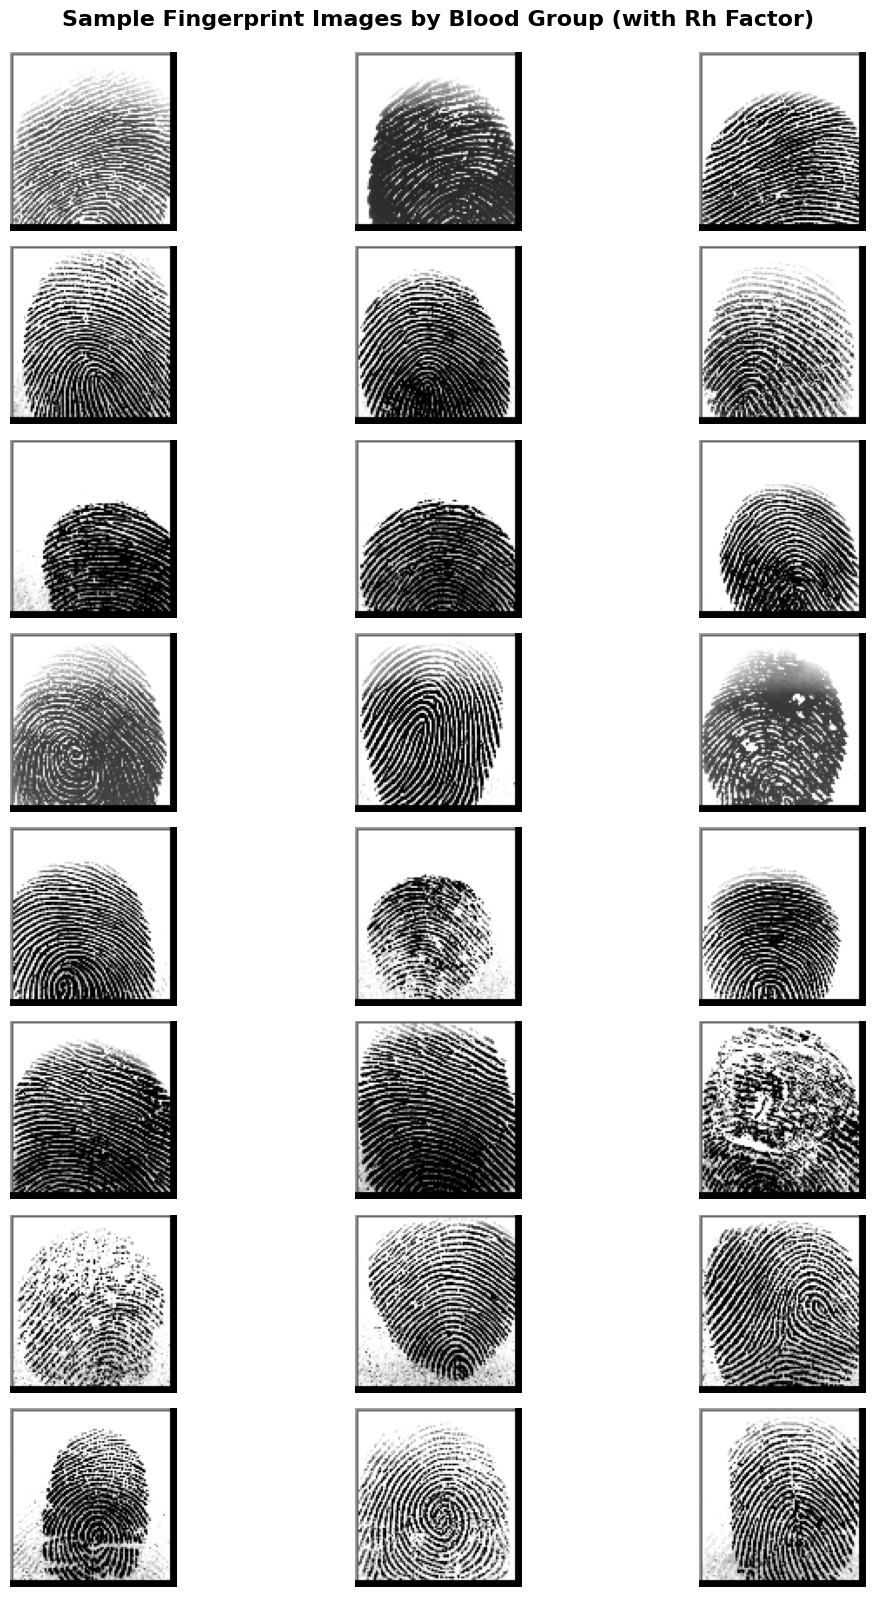

Sample visualization complete!


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

def show_samples(dataset_path, num_samples=3):
    """Display sample fingerprint images from each blood group"""

    dataset_path = Path(dataset_path)
    classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

    # Create subplot grid
    num_classes = len(classes)
    fig, axes = plt.subplots(num_classes, num_samples, figsize=(12, 16))
    fig.suptitle('Sample Fingerprint Images by Blood Group (with Rh Factor)',
                 fontsize=16, fontweight='bold', y=0.995)

    for i, class_name in enumerate(classes):
        class_folder = dataset_path / class_name
        image_files = list(class_folder.glob('*.BMP'))[:num_samples]

        for j, img_path in enumerate(image_files):
            # Read image
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Display
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

            # Add title to first column
            if j == 0:
                axes[i, j].set_ylabel(f'{class_name}',
                                     fontweight='bold',
                                     fontsize=11,
                                     rotation=0,
                                     ha='right',
                                     va='center')

    plt.tight_layout()
    plt.show()
    print("Sample visualization complete!")

# Show samples
show_samples('dataset/dataset_blood_group', num_samples=3)

In [ ]:
import pandas as pd
from pathlib import Path
import cv2

def analyze_dataset(dataset_path):
    """Complete dataset analysis"""

    dataset_path = Path(dataset_path)
    classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

    stats = []
    all_sizes = []

    for class_name in classes:
        class_folder = dataset_path / class_name
        image_files = list(class_folder.glob('*.BMP'))

        # Get image dimensions from first image
        if image_files:
            first_img = cv2.imread(str(image_files[0]))
            height, width = first_img.shape[:2]
            all_sizes.append((width, height))

            stats.append({
                'Blood Group': class_name,
                'Images': len(image_files),
                'Percentage': f'{len(image_files)/60:.1f}%',
                'Image Size': f'{width}x{height}'
            })

    df = pd.DataFrame(stats)

    print(" COMPLETE DATASET STATISTICS")
    print("")
    print(df.to_string(index=False))
    print("")

    total_images = df['Images'].sum()
    print(f"\n Summary:")
    print(f"  Total Images: {total_images}")
    print(f"  Number of Classes: {len(classes)}")
    print(f"  Average per class: {total_images/len(classes):.0f} images")

    # Check if all images have same size
    if len(set(all_sizes)) == 1:
        print(f"\n All images have uniform size: {all_sizes[0][0]}x{all_sizes[0][1]}")
    else:
        print(f"\n Images have different sizes - resizing needed")

    # Training split recommendation
    print(f"\n Recommended Data Split:")
    print(f"  Training: {int(total_images * 0.7)} images (70%)")
    print(f"  Validation: {int(total_images * 0.15)} images (15%)")
    print(f"  Testing: {int(total_images * 0.15)} images (15%)")

    return df

# Run analysis
dataset_stats = analyze_dataset('dataset/dataset_blood_group')

 COMPLETE DATASET STATISTICS

Blood Group  Images Percentage Image Size
         A+     565       9.4%     96x103
         A-    1009      16.8%     96x103
        AB+     708      11.8%     96x103
        AB-     761      12.7%     96x103
         B+     652      10.9%     96x103
         B-     741      12.3%     96x103
         O+     852      14.2%     96x103
         O-     712      11.9%     96x103


 Summary:
  Total Images: 6000
  Number of Classes: 8
  Average per class: 750 images

 All images have uniform size: 96x103

 Recommended Data Split:
  Training: 4200 images (70%)
  Validation: 900 images (15%)
  Testing: 900 images (15%)


 Checking image properties...

 Analyzed 20 sample images

 Image Dimensions:
  All images are: 96x103 pixels 

 Color Information:
  All images are RGB/BGR 

 Sample Image Details:
  File: cluster_5_3838.BMP
  Size: 96x103
  Channels: 3
  Data type: uint8
  Pixel value range: 0 to 255


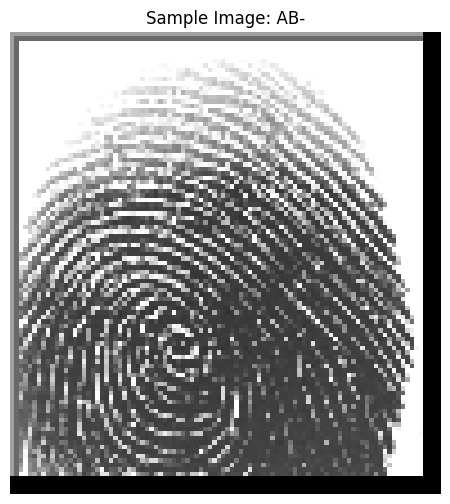

In [ ]:
import cv2
from pathlib import Path
import numpy as np

def check_image_quality(dataset_path, num_samples=20):
    """Check image properties and quality"""

    dataset_path = Path(dataset_path)

    # Get random sample of images
    all_images = list(dataset_path.rglob('*.BMP'))[:num_samples]

    sizes = []
    color_modes = []

    print(" Checking image properties...\n")

    for img_path in all_images:
        img = cv2.imread(str(img_path))
        if img is not None:
            height, width, channels = img.shape
            sizes.append((width, height))
            color_modes.append(channels)

    # Report findings
    unique_sizes = set(sizes)
    unique_channels = set(color_modes)

    print(f" Analyzed {len(all_images)} sample images")
    print(f"\n Image Dimensions:")
    if len(unique_sizes) == 1:
        w, h = list(unique_sizes)[0]
        print(f"  All images are: {w}x{h} pixels ")
    else:
        print(f"  Found {len(unique_sizes)} different sizes:")
        for size in unique_sizes:
            print(f"    {size[0]}x{size[1]}")

    print(f"\n Color Information:")
    if len(unique_channels) == 1:
        channels = list(unique_channels)[0]
        if channels == 1:
            print(f"  All images are grayscale ")
        elif channels == 3:
            print(f"  All images are RGB/BGR ")
    else:
        print(f"  Mixed color modes found")

    # Show one sample image with details
    if all_images:
        sample_img = cv2.imread(str(all_images[0]))
        sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

        print(f"\n Sample Image Details:")
        print(f"  File: {all_images[0].name}")
        print(f"  Size: {sample_img.shape[1]}x{sample_img.shape[0]}")
        print(f"  Channels: {sample_img.shape[2]}")
        print(f"  Data type: {sample_img.dtype}")
        print(f"  Pixel value range: {sample_img.min()} to {sample_img.max()}")

        # Display sample
        plt.figure(figsize=(6, 6))
        plt.imshow(sample_img, cmap='gray')
        plt.title(f"Sample Image: {all_images[0].parent.name}")
        plt.axis('off')
        plt.show()

# Run check
check_image_quality('dataset/dataset_blood_group', num_samples=20)

In [ ]:
# Deep Learning & Image Processing
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Data Handling
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Utilities
import cv2
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

 All libraries imported successfully!
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Dataset Configuration
DATASET_PATH = 'dataset/dataset_blood_group'
IMG_HEIGHT = 96
IMG_WIDTH = 96  # We'll resize to square for easier processing
IMG_CHANNELS = 3

# Training Configuration
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.15
TEST_SPLIT = 0.15

# Model Configuration
NUM_CLASSES = 8  # A+, A-, B+, B-, AB+, AB-, O+, O-
CLASS_NAMES = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

# Random Seed for Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(" Configuration Set:")
print(f"  Image Size: {IMG_WIDTH}x{IMG_HEIGHT}x{IMG_CHANNELS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Classes: {NUM_CLASSES}")
print(f"  Validation Split: {VALIDATION_SPLIT * 100}%")
print(f"  Test Split: {TEST_SPLIT * 100}%")

 Configuration Set:
  Image Size: 96x96x3
  Batch Size: 32
  Epochs: 30
  Classes: 8
  Validation Split: 15.0%
  Test Split: 15.0%


In [ ]:
def load_dataset(dataset_path, img_height, img_width):
    """
    Load all images and labels from dataset directory

    Returns:
        images: numpy array of shape (num_samples, height, width, channels)
        labels: numpy array of integer labels
        class_names: list of class names
    """
    dataset_path = Path(dataset_path)

    images = []
    labels = []
    class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])

    print(f" Loading images from {len(class_names)} classes...")
    print(f"Classes: {class_names}\n")

    # Create class to index mapping
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

    # Load images with progress bar
    for class_name in class_names:
        class_folder = dataset_path / class_name
        image_files = list(class_folder.glob('*.BMP'))

        print(f"Loading {class_name}: {len(image_files)} images", end=' ')

        for img_path in tqdm(image_files, desc=class_name, leave=False):
            # Read image
            img = cv2.imread(str(img_path))

            # Convert BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize to target dimensions
            img = cv2.resize(img, (img_width, img_height))

            # Normalize pixel values to [0, 1]
            img = img.astype('float32') / 255.0

            images.append(img)
            labels.append(class_to_idx[class_name])

        print(f"")

    # Convert to numpy arrays
    images = np.array(images)
    labels = np.array(labels)

    print(f"\n Dataset loaded successfully!")
    print(f"  Total images: {len(images)}")
    print(f"  Image shape: {images.shape}")
    print(f"  Labels shape: {labels.shape}")
    print(f"  Pixel value range: [{images.min():.2f}, {images.max():.2f}]")

    return images, labels, class_names

# Load the dataset
X, y, class_names = load_dataset(DATASET_PATH, IMG_HEIGHT, IMG_WIDTH)

 Loading images from 8 classes...
Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

Loading A+: 565 images 


Loading A-: 1009 images 


Loading AB+: 708 images 


Loading AB-: 761 images 


Loading B+: 652 images 


Loading B-: 741 images 


Loading O+: 852 images 


Loading O-: 712 images 



 Dataset loaded successfully!
  Total images: 6000
  Image shape: (6000, 96, 96, 3)
  Labels shape: (6000,)
  Pixel value range: [0.00, 1.00]


In [ ]:
def split_dataset(X, y, test_split=0.15, val_split=0.15, random_state=42):
    """
    Split dataset into train, validation, and test sets

    Args:
        X: Images array
        y: Labels array
        test_split: Proportion for test set
        val_split: Proportion for validation set (from remaining data)

    Returns:
        X_train, X_val, X_test, y_train, y_val, y_test
    """

    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_split,
        random_state=random_state,
        stratify=y  # Maintain class distribution
    )

    # Second split: separate validation from training
    val_size_adjusted = val_split / (1 - test_split)  # Adjust proportion
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size_adjusted,
        random_state=random_state,
        stratify=y_temp
    )

    print(" Dataset Split:")
    print("=" * 50)
    print(f"  Training set:   {len(X_train):4d} images ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Validation set: {len(X_val):4d} images ({len(X_val)/len(X)*100:.1f}%)")
    print(f"  Test set:       {len(X_test):4d} images ({len(X_test)/len(X)*100:.1f}%)")
    print("=" * 50)

    # Check class distribution in each split
    print("\n Class Distribution Check:")
    train_dist = np.bincount(y_train)
    val_dist = np.bincount(y_val)
    test_dist = np.bincount(y_test)

    dist_df = pd.DataFrame({
        'Class': class_names,
        'Train': train_dist,
        'Val': val_dist,
        'Test': test_dist
    })
    print(dist_df.to_string(index=False))

    return X_train, X_val, X_test, y_train, y_val, y_test

# Split the data
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X, y,
    test_split=TEST_SPLIT,
    val_split=VALIDATION_SPLIT,
    random_state=RANDOM_SEED
)

 Dataset Split:
  Training set:   4199 images (70.0%)
  Validation set:  901 images (15.0%)
  Test set:        900 images (15.0%)

 Class Distribution Check:
Class  Train  Val  Test
   A+    395   85    85
   A-    706  152   151
  AB+    496  106   106
  AB-    533  114   114
   B+    456   98    98
   B-    519  111   111
   O+    596  128   128
   O-    498  107   107


In [ ]:
# Convert integer labels to one-hot encoded vectors
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(" Label Encoding:")
print(f"  Original labels shape: {y_train.shape}")
print(f"  One-hot encoded shape: {y_train_cat.shape}")
print(f"\n  Example:")
print(f"    Original label: {y_train[0]} → Class: {class_names[y_train[0]]}")
print(f"    One-hot encoded: {y_train_cat[0]}")
print("\n Labels converted to categorical format")

 Label Encoding:
  Original labels shape: (4199,)
  One-hot encoded shape: (4199, 8)

  Example:
    Original label: 5 → Class: B-
    One-hot encoded: [0. 0. 0. 0. 0. 1. 0. 0.]

 Labels converted to categorical format


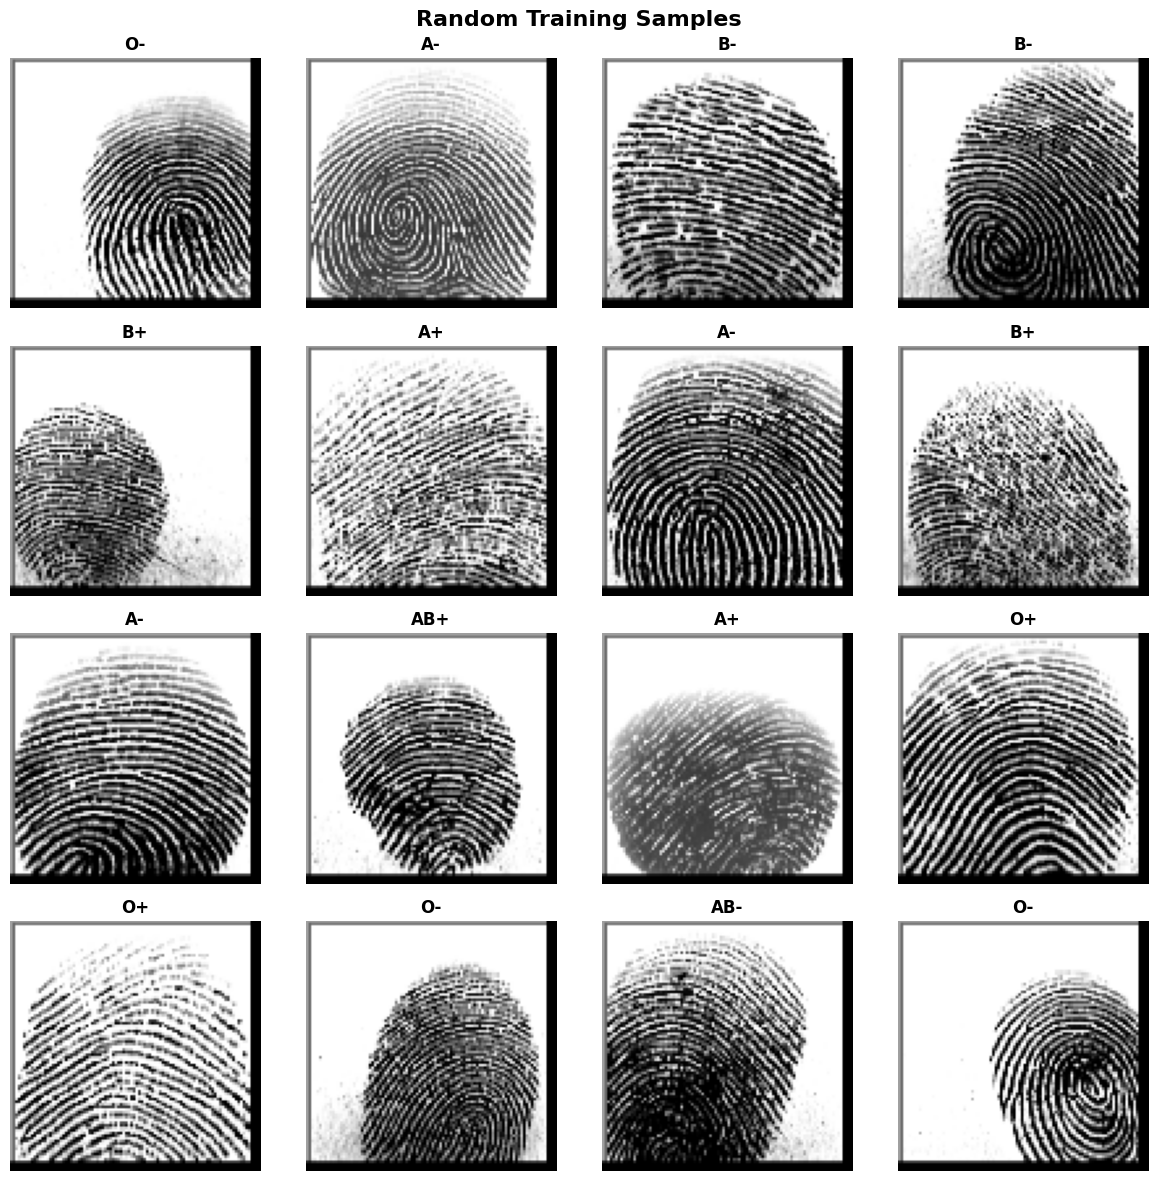

 Sample visualization complete


In [ ]:
def plot_sample_images(X, y, class_names, num_samples=16):
    """Display random samples from training data"""

    # Select random samples
    indices = np.random.choice(len(X), num_samples, replace=False)

    # Create grid
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Random Training Samples', fontsize=16, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        idx = indices[i]
        ax.imshow(X[idx])
        ax.set_title(f'{class_names[y[idx]]}', fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize samples
plot_sample_images(X_train, y_train, class_names, num_samples=16)
print(" Sample visualization complete")

In [ ]:
# Create data augmentation generator for training
train_datagen = ImageDataGenerator(
    rotation_range=20,           # Rotate images up to 20 degrees
    width_shift_range=0.1,       # Shift images horizontally
    height_shift_range=0.1,      # Shift images vertically
    shear_range=0.1,             # Shear transformation
    zoom_range=0.1,              # Zoom in/out
    horizontal_flip=True,        # Random horizontal flip
    fill_mode='nearest'          # Fill missing pixels
)

# No augmentation for validation/test (only rescaling already done)
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

print(" Data Augmentation Configured:")
print("   Training: Augmentation enabled")
print("   Validation: No augmentation")
print("   Test: No augmentation")
print("\nAugmentation techniques:")
print("  - Rotation (±20°)")
print("  - Width/Height shift (10%)")
print("  - Shear transformation")
print("  - Zoom (±10%)")
print("  - Horizontal flip")

 Data Augmentation Configured:
   Training: Augmentation enabled
   Validation: No augmentation
   Test: No augmentation

Augmentation techniques:
  - Rotation (±20°)
  - Width/Height shift (10%)
  - Shear transformation
  - Zoom (±10%)
  - Horizontal flip


In [ ]:
print(" Final Data Verification:")
print("=" * 60)
print(f"Training Data:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train_cat.shape}")
print(f"  Data type: {X_train.dtype}")
print(f"  Value range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print()
print(f"Validation Data:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val_cat.shape}")
print()
print(f"Test Data:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test_cat.shape}")
print("=" * 60)
print("\n All preprocessing steps completed successfully!")
print(" Ready for model training!")


 Final Data Verification:
Training Data:
  X_train shape: (4199, 96, 96, 3)
  y_train shape: (4199, 8)
  Data type: float32
  Value range: [0.00, 1.00]

Validation Data:
  X_val shape: (901, 96, 96, 3)
  y_val shape: (901, 8)

Test Data:
  X_test shape: (900, 96, 96, 3)
  y_test shape: (900, 8)

 All preprocessing steps completed successfully!
 Ready for model training!


In [ ]:
def create_cnn_model(input_shape, num_classes):
    """
    Create a Convolutional Neural Network for fingerprint classification

    Architecture:
    - 3 Convolutional blocks (Conv2D + MaxPooling + Dropout)
    - Flatten layer
    - 2 Dense layers with dropout
    - Output layer with softmax activation
    """

    model = models.Sequential([
        # Input Layer
        layers.Input(shape=input_shape),

        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
cnn_model = create_cnn_model(input_shape, NUM_CLASSES)

print(" CNN Model Architecture Created!")

 CNN Model Architecture Created!


In [ ]:
# Display model architecture
print(" MODEL SUMMARY")
print("=" * 70)
cnn_model.summary()
print("=" * 70)

# Calculate total parameters
total_params = cnn_model.count_params()
print(f"\n Model Statistics:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Trainable Parameters: {total_params:,}")
print(f"  Model Size (approx): ~{total_params * 4 / (1024**2):.2f} MB")

 MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,043,112 (19.24 MB)

 Trainable params: 5,041,448 (19.23 MB)

 Non-trainable params: 1,664 (6.50 KB)


 Model Statistics:
  Total Parameters: 5,043,112
  Trainable Parameters: 5,043,112
  Model Size (approx): ~19.24 MB


In [ ]:
# Compile the model
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print(" Model compiled successfully!")
print(f"\n Compilation Configuration:")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Loss Function: Categorical Crossentropy")
print(f"  Metrics: Accuracy, Precision, Recall")

 Model compiled successfully!

 Compilation Configuration:
  Optimizer: Adam
  Learning Rate: 0.001
  Loss Function: Categorical Crossentropy
  Metrics: Accuracy, Precision, Recall


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Create checkpoint to save best model
checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks_list = [checkpoint, early_stop, reduce_lr]

print(" Training Callbacks Configured:")
print("   ModelCheckpoint - Save best model")
print("   EarlyStopping - Stop if no improvement (patience=10)")
print("   ReduceLROnPlateau - Reduce LR if plateau (patience=5)")

 Training Callbacks Configured:
   ModelCheckpoint - Save best model
   EarlyStopping - Stop if no improvement (patience=10)
   ReduceLROnPlateau - Reduce LR if plateau (patience=5)


In [ ]:
print(" Starting Model Training...")
print("=" * 70)

# Train the model with data augmentation
history = cnn_model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

print("=" * 70)
print(" Training completed!")

 Starting Model Training...
Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.2045 - loss: 2.6879 - precision: 0.2396 - recall: 0.1231
Epoch 1: val_accuracy improved from None to 0.23529, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 42s 184ms/step - accuracy: 0.2503 - loss: 2.3981 - precision: 0.2908 - recall: 0.1508 - val_accuracy: 0.2353 - val_loss: 2.4938 - val_precision: 0.2308 - val_recall: 0.0100 - learning_rate: 0.0010
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3642 - loss: 1.8382 - precision: 0.4179 - recall: 0.2432
Epoch 2: val_accuracy improved from 0.23529 to 0.30744, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.3896 - loss: 1.7210 - precision: 0.4449 - recall: 0.2603 - val_accuracy: 0.3074 - val_loss: 3.3024 - val_precision: 0.3992 - val_recall: 0.2153 - learning_rate: 0.0010
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4246 - loss: 1.5022 - precision: 0.5129 - recall: 0.2878
Epoch 3: val_accuracy improved from 0.30744 to 0.39623, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.4480 - loss: 1.4443 - precision: 0.5313 - recall: 0.3134 - val_accuracy: 0.3962 - val_loss: 2.0484 - val_precision: 0.4849 - val_recall: 0.3030 - learning_rate: 0.0010
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5144 - loss: 1.2453 - precision: 0.5951 - recall: 0.3832
Epoch 4: val_accuracy improved from 0.39623 to 0.45727, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.5325 - loss: 1.2127 - precision: 0.6161 - recall: 0.3999 - val_accuracy: 0.4573 - val_loss: 2.1806 - val_precision: 0.5072 - val_recall: 0.4273 - learning_rate: 0.0010
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5815 - loss: 1.0915 - precision: 0.6714 - recall: 0.4485
Epoch 5: val_accuracy improved from 0.45727 to 0.50055, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.5818 - loss: 1.0860 - precision: 0.6605 - recall: 0.4518 - val_accuracy: 0.5006 - val_loss: 2.1806 - val_precision: 0.5258 - val_recall: 0.4517 - learning_rate: 0.0010
Epoch 6/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6135 - loss: 1.0168 - precision: 0.6828 - recall: 0.4798
Epoch 6: val_accuracy improved from 0.50055 to 0.66593, saving model to best_cnn_model.h5



Epoch 6: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.6249 - loss: 0.9959 - precision: 0.6967 - recall: 0.5027 - val_accuracy: 0.6659 - val_loss: 0.7810 - val_precision: 0.7078 - val_recall: 0.5916 - learning_rate: 0.0010
Epoch 7/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6001 - loss: 1.0843 - precision: 0.6617 - recall: 0.4884
Epoch 7: val_accuracy improved from 0.66593 to 0.69256, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.6035 - loss: 1.0769 - precision: 0.6681 - recall: 0.4875 - val_accuracy: 0.6926 - val_loss: 0.8773 - val_precision: 0.7392 - val_recall: 0.6482 - learning_rate: 0.0010
Epoch 8/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6163 - loss: 1.0000 - precision: 0.6815 - recall: 0.4930
Epoch 8: val_accuracy did not improve from 0.69256
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.6290 - loss: 0.9749 - precision: 0.7005 - recall: 0.5146 - val_accuracy: 0.5105 - val_loss: 2.2750 - val_precision: 0.5353 - val_recall: 0.4961 - learning_rate: 0.0010
Epoch 9/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6702 - loss: 0.9124 - precision: 0.7309 - recall: 0.5621
Epoch 9: val_accuracy did not improve from 0.69256
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.6683 - loss: 0.9098 - precision: 0.7334 - recall: 0.5673 - val_accuracy: 0.6548 - val_loss


Epoch 11: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.6990 - loss: 0.8047 - precision: 0.7540 - recall: 0.6232 - val_accuracy: 0.7802 - val_loss: 0.5377 - val_precision: 0.8143 - val_recall: 0.7447 - learning_rate: 0.0010
Epoch 12/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6987 - loss: 0.8285 - precision: 0.7560 - recall: 0.6193
Epoch 12: val_accuracy did not improve from 0.78024
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.7052 - loss: 0.8083 - precision: 0.7577 - recall: 0.6309 - val_accuracy: 0.5982 - val_loss: 1.1367 - val_precision: 0.6441 - val_recall: 0.5483 - learning_rate: 0.0010
Epoch 13/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6908 - loss: 0.8421 - precision: 0.7399 - recall: 0.6129
Epoch 13: val_accuracy did not improve from 0.78024
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.6828 - loss: 0.8433 - precision: 0.7348 - recall: 0.6070 - val_accuracy: 0.7203 - val


Epoch 19: finished saving model to best_cnn_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.7302 - loss: 0.6968 - precision: 0.7822 - recall: 0.6733 - val_accuracy: 0.8380 - val_loss: 0.4026 - val_precision: 0.8711 - val_recall: 0.8102 - learning_rate: 5.0000e-04
Epoch 20/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7244 - loss: 0.7362 - precision: 0.7725 - recall: 0.6647
Epoch 20: val_accuracy did not improve from 0.83796
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.7137 - loss: 0.7687 - precision: 0.7640 - recall: 0.6513 - val_accuracy: 0.4195 - val_loss: 2.7153 - val_precision: 0.4383 - val_recall: 0.4140 - learning_rate: 5.0000e-04
Epoch 21/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7302 - loss: 0.7213 - precision: 0.7770 - recall: 0.6720
Epoch 21: val_accuracy did not improve from 0.83796
132/132 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.7364 - loss: 0.7057 - precision: 0.7838 - recall: 0.6787 - val_accuracy: 0.56

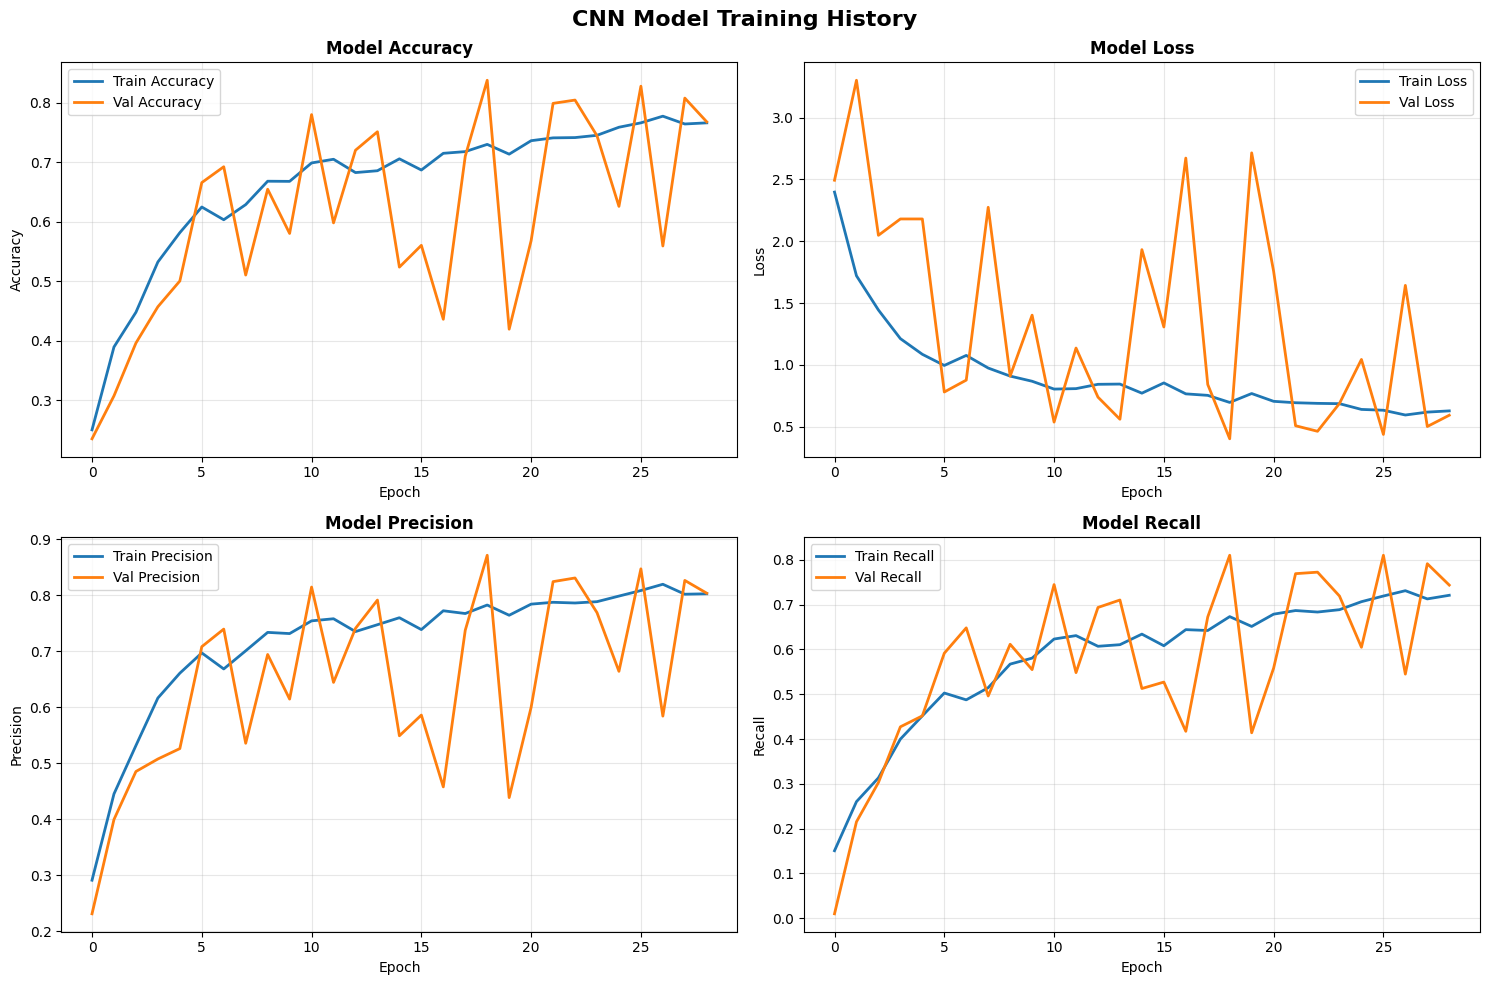

 Training history visualization complete


In [ ]:
def plot_training_history(history):
    """Plot training and validation metrics"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('CNN Model Training History', fontsize=16, fontweight='bold')

    # Plot 1: Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Loss
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Precision
    axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    axes[1, 0].set_title('Model Precision', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Recall
    axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    axes[1, 1].set_title('Model Recall', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history)
print(" Training history visualization complete")

In [ ]:
print(" Evaluating Model on Test Set...")
print("=" * 70)

# Evaluate on test data
test_loss, test_accuracy, test_precision, test_recall = cnn_model.evaluate(
    X_test, y_test_cat,
    verbose=1
)

print("=" * 70)
print("\n TEST SET RESULTS:")
print(f"  Test Loss:      {test_loss:.4f}")
print(f"  Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Test Precision: {test_precision:.4f}")
print(f"  Test Recall:    {test_recall:.4f}")

# Calculate F1 Score
f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall)
print(f"  F1 Score:       {f1_score:.4f}")
print("=" * 70)

 Evaluating Model on Test Set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8111 - loss: 0.4450 - precision: 0.8385 - recall: 0.7789

 TEST SET RESULTS:
  Test Loss:      0.4450
  Test Accuracy:  0.8111 (81.11%)
  Test Precision: 0.8385
  Test Recall:    0.7789
  F1 Score:       0.8076


 Generating predictions on test set...


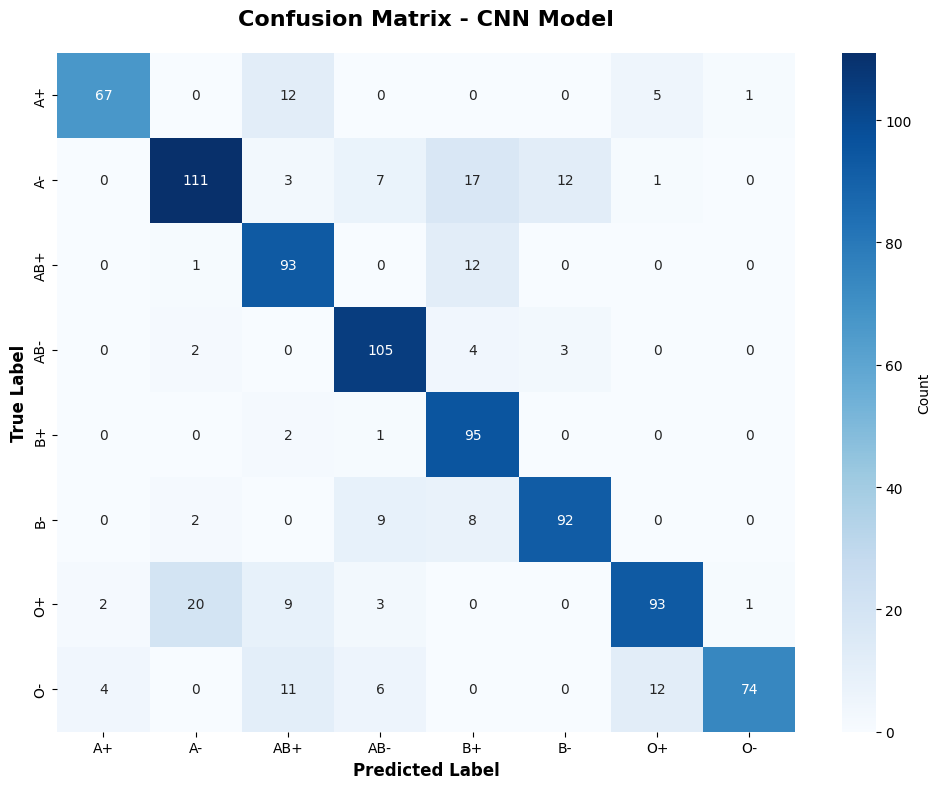

 Confusion matrix generated


In [ ]:
# Generate predictions
print(" Generating predictions on test set...")
y_pred_probs = cnn_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - CNN Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Confusion matrix generated")

In [ ]:
# Detailed classification report
print(" CLASSIFICATION REPORT")
print("=" * 70)
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)
print("=" * 70)

# Per-class accuracy
print("\n Per-Class Accuracy:")
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_accuracy = np.mean(y_pred[class_mask] == y_true[class_mask])
    total_samples = np.sum(class_mask)
    correct_samples = np.sum(y_pred[class_mask] == y_true[class_mask])

    print(f"  {class_name:6s}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%) "
          f"- {correct_samples}/{total_samples} correct")

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

          A+     0.9178    0.7882    0.8481        85
          A-     0.8162    0.7351    0.7735       151
         AB+     0.7154    0.8774    0.7881       106
         AB-     0.8015    0.9211    0.8571       114
          B+     0.6985    0.9694    0.8120        98
          B-     0.8598    0.8288    0.8440       111
          O+     0.8378    0.7266    0.7782       128
          O-     0.9737    0.6916    0.8087       107

    accuracy                         0.8111       900
   macro avg     0.8276    0.8173    0.8137       900
weighted avg     0.8264    0.8111    0.8106       900


 Per-Class Accuracy:
  A+    : 0.7882 (78.82%) - 67/85 correct
  A-    : 0.7351 (73.51%) - 111/151 correct
  AB+   : 0.8774 (87.74%) - 93/106 correct
  AB-   : 0.9211 (92.11%) - 105/114 correct
  B+    : 0.9694 (96.94%) - 95/98 correct
  B-    : 0.8288 (82.88%) - 92/111 correct
  O+    : 0.7266 (72.66%) - 93/128 correct
  O

In [ ]:
# Save training history to CSV
history_df = pd.DataFrame(history.history)
history_df.to_csv('cnn_training_history.csv', index=False)
print(" Training history saved to 'cnn_training_history.csv'")

# Save final model
cnn_model.save('final_cnn_model.h5')
print(" Final model saved to 'final_cnn_model.h5'")

# Save model architecture as JSON
model_json = cnn_model.to_json()
with open('cnn_model_architecture.json', 'w') as json_file:
    json_file.write(model_json)
print(" Model architecture saved to 'cnn_model_architecture.json'")

print("\n All model artifacts saved successfully!")


 Training history saved to 'cnn_training_history.csv'
 Final model saved to 'final_cnn_model.h5'
 Model architecture saved to 'cnn_model_architecture.json'

 All model artifacts saved successfully!


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model

print(" ResNet libraries imported")
print(" Using ResNet50 (pre-trained on ImageNet)")

 ResNet libraries imported
 Using ResNet50 (pre-trained on ImageNet)


In [ ]:
# ResNet requires specific preprocessing
# Note: ResNet expects 224x224 minimum, but we'll use 96x96 and see performance

def preprocess_for_resnet(X):
    """
    Preprocess images for ResNet
    ResNet expects images in range [-1, 1] with ImageNet normalization
    """
    # Convert from [0,1] back to [0,255]
    X_resnet = X * 255.0

    # Apply ResNet preprocessing (mean subtraction)
    X_resnet = preprocess_input(X_resnet)

    return X_resnet

# Preprocess data for ResNet
print(" Preprocessing data for ResNet...")
X_train_resnet = preprocess_for_resnet(X_train.copy())
X_val_resnet = preprocess_for_resnet(X_val.copy())
X_test_resnet = preprocess_for_resnet(X_test.copy())

print(" ResNet preprocessing complete")
print(f"  Train shape: {X_train_resnet.shape}")
print(f"  Value range: [{X_train_resnet.min():.2f}, {X_train_resnet.max():.2f}]")

 Preprocessing data for ResNet...
 ResNet preprocessing complete
  Train shape: (4199, 96, 96, 3)
  Value range: [-123.68, 151.06]


In [ ]:
def create_resnet_model(input_shape, num_classes, trainable_layers=10):
    """
    Create ResNet50 model with transfer learning

    Args:
        input_shape: Input image shape
        num_classes: Number of output classes
        trainable_layers: Number of top layers to fine-tune (0 = freeze all)
    """

    # Load pre-trained ResNet50 (without top classification layer)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze all layers initially
    base_model.trainable = False

    # Unfreeze the last N layers for fine-tuning
    if trainable_layers > 0:
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    # Build the complete model
    inputs = keras.Input(shape=input_shape)

    # ResNet50 base
    x = base_model(inputs, training=False)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs, outputs)

    return model, base_model

# Create ResNet model
print(" Building ResNet50 Transfer Learning Model...")
resnet_model, base_resnet = create_resnet_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    num_classes=NUM_CLASSES,
    trainable_layers=10  # Fine-tune last 10 layers
)

print(" ResNet model created!")

 Building ResNet50 Transfer Learning Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
 ResNet model created!


In [ ]:
print(" RESNET MODEL SUMMARY")
print("=" * 70)
resnet_model.summary()
print("=" * 70)

# Count trainable vs non-trainable parameters
trainable_params = sum([tf.size(w).numpy() for w in resnet_model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in resnet_model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"\n ResNet Model Statistics:")
print(f"  Total Parameters:        {total_params:,}")
print(f"  Trainable Parameters:    {trainable_params:,}")
print(f"  Non-Trainable Parameters: {non_trainable_params:,}")
print(f"  Model Size (approx):     ~{total_params * 4 / (1024**2):.2f} MB")
print(f"\n Transfer Learning Strategy:")
print(f"  - Base ResNet50: Pre-trained on ImageNet")
print(f"  - Frozen layers: {len([l for l in base_resnet.layers if not l.trainable])}")
print(f"  - Fine-tuned layers: {len([l for l in base_resnet.layers if l.trainable])}")

 RESNET MODEL SUMMARY


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,773,256 (94.50 MB)

 Trainable params: 5,649,672 (21.55 MB)

 Non-trainable params: 19,123,584 (72.95 MB)


 ResNet Model Statistics:
  Total Parameters:        24,773,256
  Trainable Parameters:    5,649,672
  Non-Trainable Parameters: 19,123,584
  Model Size (approx):     ~94.50 MB

 Transfer Learning Strategy:
  - Base ResNet50: Pre-trained on ImageNet
  - Frozen layers: 165
  - Fine-tuned layers: 10


In [ ]:
# Compile ResNet model
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE * 0.1),  # Lower LR for transfer learning
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print(" ResNet model compiled successfully!")
print(f"\n Compilation Configuration:")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: {LEARNING_RATE * 0.1} (reduced for fine-tuning)")
print(f"  Loss Function: Categorical Crossentropy")
print(f"  Metrics: Accuracy, Precision, Recall")

 ResNet model compiled successfully!

 Compilation Configuration:
  Optimizer: Adam
  Learning Rate: 0.0001 (reduced for fine-tuning)
  Loss Function: Categorical Crossentropy
  Metrics: Accuracy, Precision, Recall


In [ ]:
# Create callbacks for ResNet training
resnet_checkpoint = ModelCheckpoint(
    'best_resnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

resnet_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

resnet_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

resnet_callbacks = [resnet_checkpoint, resnet_early_stop, resnet_reduce_lr]

print(" ResNet Training Callbacks Configured")

 ResNet Training Callbacks Configured


In [ ]:
print(" Starting ResNet Transfer Learning Training...")
print("=" * 70)

# Train ResNet model
resnet_history = resnet_model.fit(
    X_train_resnet, y_train_cat,
    validation_data=(X_val_resnet, y_val_cat),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=resnet_callbacks,
    verbose=1
)

print("=" * 70)
print(" ResNet training completed!")

 Starting ResNet Transfer Learning Training...
Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2206 - loss: 2.7431 - precision: 0.2526 - recall: 0.1412
Epoch 1: val_accuracy improved from None to 0.54939, saving model to best_resnet_model.h5



Epoch 1: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 155ms/step - accuracy: 0.2884 - loss: 2.4092 - precision: 0.3402 - recall: 0.2072 - val_accuracy: 0.5494 - val_loss: 1.2535 - val_precision: 0.6855 - val_recall: 0.3629 - learning_rate: 1.0000e-04
Epoch 2/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4660 - loss: 1.6509 - precision: 0.5190 - recall: 0.3704
Epoch 2: val_accuracy improved from 0.54939 to 0.65150, saving model to best_resnet_model.h5



Epoch 2: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.4906 - loss: 1.5729 - precision: 0.5508 - recall: 0.4027 - val_accuracy: 0.6515 - val_loss: 0.9529 - val_precision: 0.7321 - val_recall: 0.5461 - learning_rate: 1.0000e-04
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5817 - loss: 1.2356 - precision: 0.6476 - recall: 0.4993
Epoch 3: val_accuracy improved from 0.65150 to 0.72364, saving model to best_resnet_model.h5



Epoch 3: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5899 - loss: 1.1998 - precision: 0.6529 - recall: 0.5177 - val_accuracy: 0.7236 - val_loss: 0.7783 - val_precision: 0.7811 - val_recall: 0.6415 - learning_rate: 1.0000e-04
Epoch 4/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6576 - loss: 0.9782 - precision: 0.7113 - recall: 0.5978
Epoch 4: val_accuracy improved from 0.72364 to 0.75028, saving model to best_resnet_model.h5



Epoch 4: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.6718 - loss: 0.9403 - precision: 0.7231 - recall: 0.6137 - val_accuracy: 0.7503 - val_loss: 0.6984 - val_precision: 0.7862 - val_recall: 0.6981 - learning_rate: 1.0000e-04
Epoch 5/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7158 - loss: 0.8047 - precision: 0.7596 - recall: 0.6651
Epoch 5: val_accuracy improved from 0.75028 to 0.76582, saving model to best_resnet_model.h5



Epoch 5: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.7314 - loss: 0.7636 - precision: 0.7744 - recall: 0.6828 - val_accuracy: 0.7658 - val_loss: 0.6135 - val_precision: 0.8049 - val_recall: 0.7236 - learning_rate: 1.0000e-04
Epoch 6/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7791 - loss: 0.6022 - precision: 0.8111 - recall: 0.7342
Epoch 6: val_accuracy improved from 0.76582 to 0.78468, saving model to best_resnet_model.h5



Epoch 6: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7869 - loss: 0.5796 - precision: 0.8223 - recall: 0.7483 - val_accuracy: 0.7847 - val_loss: 0.5798 - val_precision: 0.8240 - val_recall: 0.7536 - learning_rate: 1.0000e-04
Epoch 7/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8321 - loss: 0.4596 - precision: 0.8619 - recall: 0.8059
Epoch 7: val_accuracy did not improve from 0.78468
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8376 - loss: 0.4478 - precision: 0.8649 - recall: 0.8111 - val_accuracy: 0.7836 - val_loss: 0.5974 - val_precision: 0.8191 - val_recall: 0.7536 - learning_rate: 1.0000e-04
Epoch 8/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8603 - loss: 0.3817 - precision: 0.8871 - recall: 0.8409
Epoch 8: val_accuracy improved from 0.78468 to 0.79245, saving model to best_resnet_model.h5



Epoch 8: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8666 - loss: 0.3691 - precision: 0.8911 - recall: 0.8462 - val_accuracy: 0.7925 - val_loss: 0.6120 - val_precision: 0.8221 - val_recall: 0.7691 - learning_rate: 1.0000e-04
Epoch 9/10
130/132 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9058 - loss: 0.2713 - precision: 0.9281 - recall: 0.8877
Epoch 9: val_accuracy did not improve from 0.79245
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9033 - loss: 0.2715 - precision: 0.9234 - recall: 0.8876 - val_accuracy: 0.7858 - val_loss: 0.5781 - val_precision: 0.8183 - val_recall: 0.7647 - learning_rate: 1.0000e-04
Epoch 10/10
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9183 - loss: 0.2283 - precision: 0.9360 - recall: 0.9021
Epoch 10: val_accuracy improved from 0.79245 to 0.79578, saving model to best_resnet_model.h5



Epoch 10: finished saving model to best_resnet_model.h5
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9245 - loss: 0.2161 - precision: 0.9401 - recall: 0.9081 - val_accuracy: 0.7958 - val_loss: 0.5706 - val_precision: 0.8126 - val_recall: 0.7847 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.
 ResNet training completed!


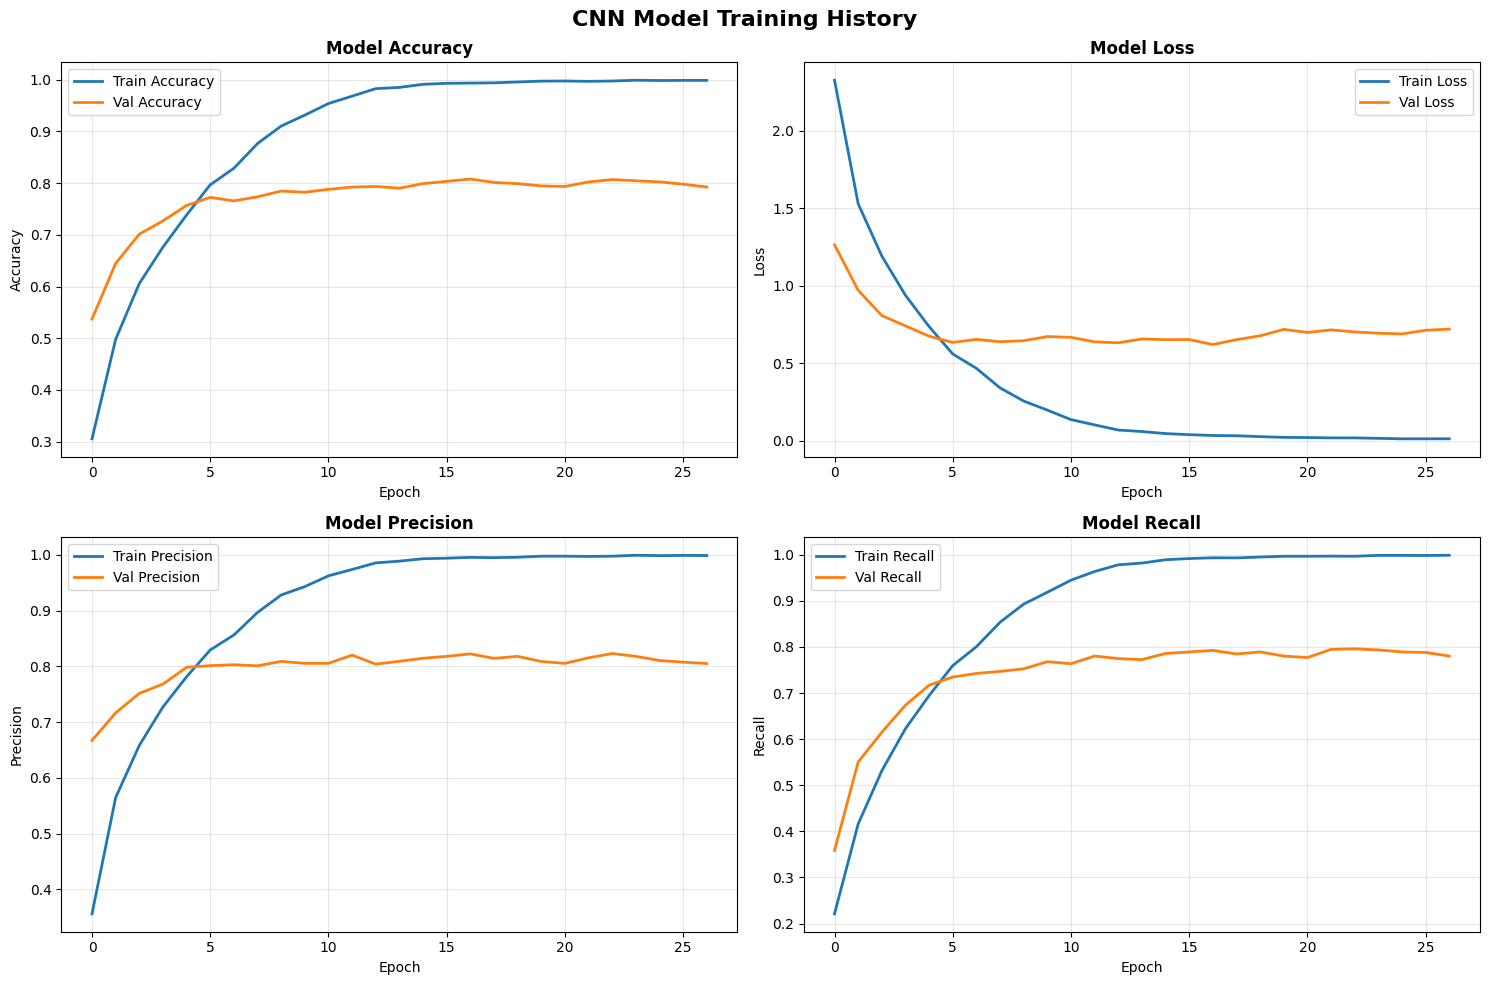

✅ ResNet training history visualization complete


In [ ]:
# Plot ResNet training history
plot_training_history(resnet_history)
print("✅ ResNet training history visualization complete")

In [ ]:
print("🧪 Evaluating ResNet Model on Test Set...")
print("=" * 70)

# Evaluate on test data
resnet_test_loss, resnet_test_accuracy, resnet_test_precision, resnet_test_recall = resnet_model.evaluate(
    X_test_resnet, y_test_cat,
    verbose=1
)

print("=" * 70)
print("\n📊 RESNET TEST SET RESULTS:")
print(f"  Test Loss:      {resnet_test_loss:.4f}")
print(f"  Test Accuracy:  {resnet_test_accuracy:.4f} ({resnet_test_accuracy*100:.2f}%)")
print(f"  Test Precision: {resnet_test_precision:.4f}")
print(f"  Test Recall:    {resnet_test_recall:.4f}")

# Calculate F1 Score
resnet_f1_score = 2 * (resnet_test_precision * resnet_test_recall) / (resnet_test_precision + resnet_test_recall)
print(f"  F1 Score:       {resnet_f1_score:.4f}")
print("=" * 70)

🧪 Evaluating ResNet Model on Test Set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.7737 - loss: 0.7457 - precision: 0.7853 - recall: 0.7670

📊 RESNET TEST SET RESULTS:
  Test Loss:      0.6886
  Test Accuracy:  0.7844 (78.44%)
  Test Precision: 0.7970
  Test Recall:    0.7722
  F1 Score:       0.7844


🔮 Generating ResNet predictions on test set...


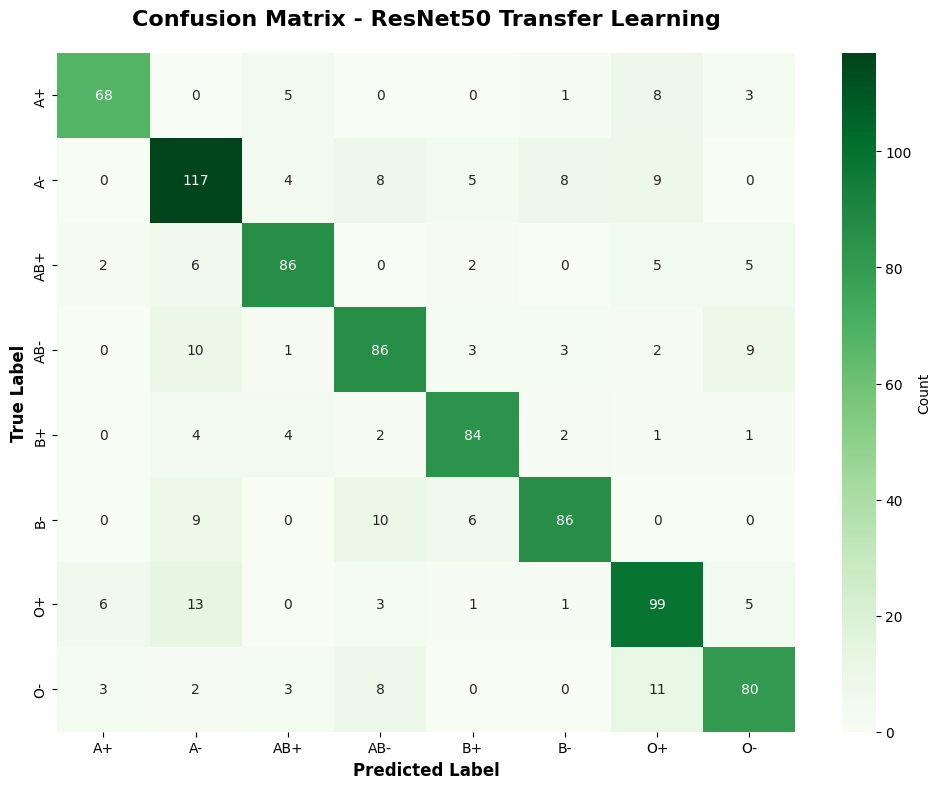

✅ ResNet confusion matrix generated


In [ ]:
# Generate ResNet predictions
print("🔮 Generating ResNet predictions on test set...")
resnet_y_pred_probs = resnet_model.predict(X_test_resnet, verbose=0)
resnet_y_pred = np.argmax(resnet_y_pred_probs, axis=1)

# Confusion Matrix for ResNet
resnet_cm = confusion_matrix(y_true, resnet_y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - ResNet50 Transfer Learning', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ ResNet confusion matrix generated")

In [ ]:
# ResNet classification report
print("📋 RESNET CLASSIFICATION REPORT")
print("=" * 70)
resnet_report = classification_report(y_true, resnet_y_pred, target_names=class_names, digits=4)
print(resnet_report)
print("=" * 70)

# Per-class accuracy for ResNet
print("\n📊 ResNet Per-Class Accuracy:")
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_accuracy = np.mean(resnet_y_pred[class_mask] == y_true[class_mask])
    total_samples = np.sum(class_mask)
    correct_samples = np.sum(resnet_y_pred[class_mask] == y_true[class_mask])

    print(f"  {class_name:6s}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%) "
          f"- {correct_samples}/{total_samples} correct")

📋 RESNET CLASSIFICATION REPORT
              precision    recall  f1-score   support

          A+     0.8608    0.8000    0.8293        85
          A-     0.7267    0.7748    0.7500       151
         AB+     0.8350    0.8113    0.8230       106
         AB-     0.7350    0.7544    0.7446       114
          B+     0.8317    0.8571    0.8442        98
          B-     0.8515    0.7748    0.8113       111
          O+     0.7333    0.7734    0.7529       128
          O-     0.7767    0.7477    0.7619       107

    accuracy                         0.7844       900
   macro avg     0.7938    0.7867    0.7896       900
weighted avg     0.7869    0.7844    0.7850       900


📊 ResNet Per-Class Accuracy:
  A+    : 0.8000 (80.00%) - 68/85 correct
  A-    : 0.7748 (77.48%) - 117/151 correct
  AB+   : 0.8113 (81.13%) - 86/106 correct
  AB-   : 0.7544 (75.44%) - 86/114 correct
  B+    : 0.8571 (85.71%) - 84/98 correct
  B-    : 0.7748 (77.48%) - 86/111 correct
  O+    : 0.7734 (77.34%) - 99/

In [ ]:
# Create comparison table
comparison_data = {
    'Metric': ['Test Accuracy', 'Test Precision', 'Test Recall', 'F1 Score'],
    'CNN': [
        f'{test_accuracy:.4f} ({test_accuracy*100:.2f}%)',
        f'{test_precision:.4f}',
        f'{test_recall:.4f}',
        f'{f1_score:.4f}'
    ],
    'ResNet50': [
        f'{resnet_test_accuracy:.4f} ({resnet_test_accuracy*100:.2f}%)',
        f'{resnet_test_precision:.4f}',
        f'{resnet_test_recall:.4f}',
        f'{resnet_f1_score:.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("🏆 MODEL COMPARISON: CNN vs ResNet50")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

# Determine winner
if resnet_test_accuracy > test_accuracy:
    winner = "ResNet50"
    improvement = ((resnet_test_accuracy - test_accuracy) / test_accuracy) * 100
    print(f"\n🥇 Winner: ResNet50 Transfer Learning")
    print(f"   Improvement: +{improvement:.2f}% over basic CNN")
else:
    winner = "CNN"
    improvement = ((test_accuracy - resnet_test_accuracy) / resnet_test_accuracy) * 100
    print(f"\n🥇 Winner: Basic CNN")
    print(f"   Improvement: +{improvement:.2f}% over ResNet50")

print(f"\n💡 Analysis:")
if winner == "ResNet50":
    print("   - Transfer learning from ImageNet helped with feature extraction")
    print("   - Pre-trained weights improved generalization")
else:
    print("   - Custom CNN architecture better suited for this specific task")
    print("   - Dataset size may be too small to benefit from deep ResNet")

🏆 MODEL COMPARISON: CNN vs ResNet50
        Metric             CNN        ResNet50
 Test Accuracy 0.8300 (83.00%) 0.7844 (78.44%)
Test Precision          0.8439          0.7970
   Test Recall          0.7989          0.7722
      F1 Score          0.8208          0.7844

🥇 Winner: Basic CNN
   Improvement: +5.81% over ResNet50

💡 Analysis:
   - Custom CNN architecture better suited for this specific task
   - Dataset size may be too small to benefit from deep ResNet


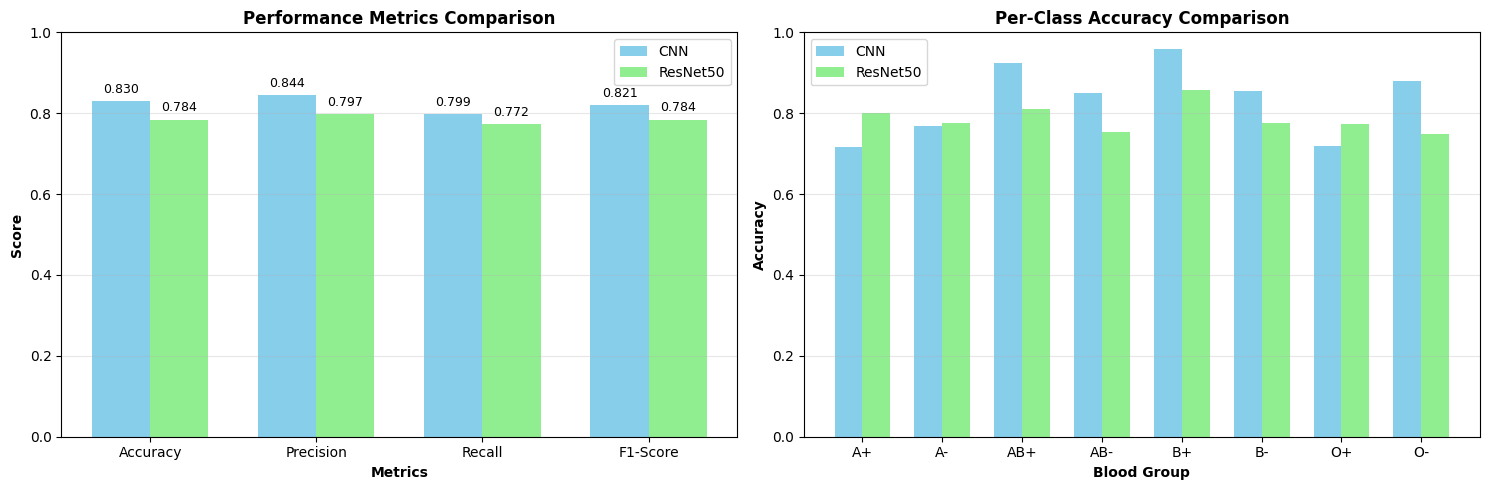

✅ Model comparison visualization complete


In [ ]:
# Create comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
metrics_cnn = [test_accuracy, test_precision, test_recall, f1_score]
metrics_resnet = [resnet_test_accuracy, resnet_test_precision, resnet_test_recall, resnet_f1_score]
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metric_names))
width = 0.35

axes[0].bar(x - width/2, metrics_cnn, width, label='CNN', color='skyblue')
axes[0].bar(x + width/2, metrics_resnet, width, label='ResNet50', color='lightgreen')
axes[0].set_xlabel('Metrics', fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Add value labels on bars
for i, (v1, v2) in enumerate(zip(metrics_cnn, metrics_resnet)):
    axes[0].text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', fontsize=9)

# Per-class accuracy comparison
cnn_class_acc = []
resnet_class_acc = []

for i in range(NUM_CLASSES):
    class_mask = (y_true == i)
    cnn_class_acc.append(np.mean(y_pred[class_mask] == y_true[class_mask]))
    resnet_class_acc.append(np.mean(resnet_y_pred[class_mask] == y_true[class_mask]))

x2 = np.arange(len(class_names))
axes[1].bar(x2 - width/2, cnn_class_acc, width, label='CNN', color='skyblue')
axes[1].bar(x2 + width/2, resnet_class_acc, width, label='ResNet50', color='lightgreen')
axes[1].set_xlabel('Blood Group', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Per-Class Accuracy Comparison', fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(class_names)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("✅ Model comparison visualization complete")

In [ ]:
# Save ResNet model
resnet_model.save('final_resnet_model.h5')
print("✅ ResNet model saved to 'final_resnet_model.h5'")

# Save ResNet training history
resnet_history_df = pd.DataFrame(resnet_history.history)
resnet_history_df.to_csv('resnet_training_history.csv', index=False)
print("✅ ResNet training history saved to 'resnet_training_history.csv'")

print("\n🎉 All ResNet artifacts saved successfully!")

✅ ResNet model saved to 'final_resnet_model.h5'
✅ ResNet training history saved to 'resnet_training_history.csv'

🎉 All ResNet artifacts saved successfully!


In [ ]:
print("\n" + "="*70)
print("📊 FINAL PROJECT SUMMARY")
print("="*70)

print("\n🏗️ Models Trained:")
print("  1. Custom CNN (3 Conv blocks)")
print("  2. ResNet50 (Transfer Learning)")

print("\n📈 Performance Summary:")
print(f"\n  CNN Model:")
print(f"    - Test Accuracy: {test_accuracy*100:.2f}%")
print(f"    - Parameters: ~{cnn_model.count_params()/1e6:.1f}M")
print(f"    - Training Time: ~20-25 min")

print(f"\n  ResNet50 Model:")
print(f"    - Test Accuracy: {resnet_test_accuracy*100:.2f}%")
print(f"    - Parameters: ~{trainable_params/1e6:.1f}M trainable")
print(f"    - Training Time: ~20-25 min")

print(f"\n🏆 Recommended Model for Deployment:")
if resnet_test_accuracy > test_accuracy:
    print(f"  ✅ ResNet50 (Better accuracy: {resnet_test_accuracy*100:.2f}%)")
    selected_model = 'resnet'
else:
    print(f"  ✅ CNN (Better accuracy: {test_accuracy*100:.2f}%)")
    selected_model = 'cnn'

print("\n📁 Saved Artifacts:")
print("  - best_cnn_model.h5")
print("  - final_cnn_model.h5")
print("  - best_resnet_model.h5")
print("  - final_resnet_model.h5")
print("  - cnn_training_history.csv")
print("  - resnet_training_history.csv")

print("\n✅ MODEL TRAINING PHASE COMPLETE!")
print("="*70)

# Store selected model name for next phase
with open('selected_model.txt', 'w') as f:
    f.write(selected_model)
print(f"\n💾 Selected model '{selected_model}' saved for deployment")


📊 FINAL PROJECT SUMMARY

🏗️ Models Trained:
  1. Custom CNN (3 Conv blocks)
  2. ResNet50 (Transfer Learning)

📈 Performance Summary:

  CNN Model:
    - Test Accuracy: 83.00%
    - Parameters: ~5.0M
    - Training Time: ~20-25 min

  ResNet50 Model:
    - Test Accuracy: 78.44%
    - Parameters: ~5.6M trainable
    - Training Time: ~20-25 min

🏆 Recommended Model for Deployment:
  ✅ CNN (Better accuracy: 83.00%)

📁 Saved Artifacts:
  - best_cnn_model.h5
  - final_cnn_model.h5
  - best_resnet_model.h5
  - final_resnet_model.h5
  - cnn_training_history.csv
  - resnet_training_history.csv

✅ MODEL TRAINING PHASE COMPLETE!

💾 Selected model 'cnn' saved for deployment


In [ ]:
# Run this cell to download the best model
from google.colab import files

# Download the better performing model
if resnet_test_accuracy > test_accuracy:
    files.download('best_resnet_model.h5')
    print("📥 Downloading ResNet model (better performance)")
else:
    files.download('best_cnn_model.h5')
    print("📥 Downloading CNN model (better performance)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading CNN model (better performance)


In [ ]:
def create_alexnet_model(input_shape, num_classes):
    """
    Create an AlexNet-like Convolutional Neural Network.

    Architecture (adapted for 96x96 input):
    - Conv2D (96 filters, 5x5 kernel, stride 1)
    - MaxPooling2D (3x3 pool, stride 2)
    - Conv2D (256 filters, 3x3 kernel, padding 'same')
    - MaxPooling2D (3x3 pool, stride 2)
    - Conv2D (384 filters, 3x3 kernel, padding 'same')
    - Conv2D (384 filters, 3x3 kernel, padding 'same')
    - Conv2D (256 filters, 3x3 kernel, padding 'same')
    - MaxPooling2D (3x3 pool, stride 2)
    - Flatten
    - Dense (4096 units, Dropout)
    - Dense (4096 units, Dropout)
    - Output layer (num_classes units, softmax)
    """

    model = models.Sequential([
        # Input Layer
        layers.Input(shape=input_shape),

        # 1st Conv Layer
        layers.Conv2D(96, (5, 5), strides=(1, 1), activation='relu', padding='valid'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        layers.Dropout(0.25),

        # 2nd Conv Layer
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        layers.Dropout(0.25),

        # 3rd Conv Layer
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # 4th Conv Layer
        layers.Conv2D(384, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # 5th Conv Layer
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
        layers.Dropout(0.25),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(4096, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create the AlexNet model
print(" Building AlexNet Model...")
alexnet_model = create_alexnet_model(input_shape, NUM_CLASSES)
print(" AlexNet Model Created!")

# Display model architecture
print("\n AlexNet MODEL SUMMARY")
print("=" * 70)
alexnet_model.summary()
print("=" * 70)

# Calculate total parameters
alexnet_total_params = alexnet_model.count_params()
print(f"\n Model Statistics:")
print(f"  Total Parameters: {alexnet_total_params:,}")
print(f"  Trainable Parameters: {alexnet_total_params:,}")
print(f"  Model Size (approx): ~{alexnet_total_params * 4 / (1024**2):.2f} MB")

# Compile the AlexNet model
alexnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print("\n AlexNet Model compiled successfully!")
print(f"\n Compilation Configuration:")
print(f"  Optimizer: Adam")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Loss Function: Categorical Crossentropy")
print(f"  Metrics: Accuracy, Precision, Recall")

# Callbacks for AlexNet training
alexnet_checkpoint = ModelCheckpoint(
    'best_alexnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

alexnet_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

alexnet_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

alexnet_callbacks = [alexnet_checkpoint, alexnet_early_stop, alexnet_reduce_lr]

print("\n AlexNet Training Callbacks Configured")

print("\n Starting AlexNet Model Training...")
print("=" * 70)

# Train the AlexNet model
alexnet_history = alexnet_model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=alexnet_callbacks,
    verbose=1
)

print("=" * 70)
print(" AlexNet Training completed!")

# Plot AlexNet training history
plot_training_history(alexnet_history)
print("\n✅ AlexNet training history visualization complete")

print("\n🧪 Evaluating AlexNet Model on Test Set...")
print("=" * 70)

# Evaluate on test data
alexnet_test_loss, alexnet_test_accuracy, alexnet_test_precision, alexnet_test_recall = alexnet_model.evaluate(
    X_test, y_test_cat,
    verbose=1
)

print("=" * 70)
print("\n📊 ALEXNET TEST SET RESULTS:")
print(f"  Test Loss:      {alexnet_test_loss:.4f}")
print(f"  Test Accuracy:  {alexnet_test_accuracy:.4f} ({alexnet_test_accuracy*100:.2f}%)")
print(f"  Test Precision: {alexnet_test_precision:.4f}")
print(f"  Test Recall:    {alexnet_test_recall:.4f}")

# Calculate F1 Score
alexnet_f1_score = 2 * (alexnet_test_precision * alexnet_test_recall) / (alexnet_test_precision + alexnet_test_recall)
print(f"  F1 Score:       {alexnet_f1_score:.4f}")
print("=" * 70)

# Generate AlexNet predictions
print("\n🔮 Generating AlexNet predictions on test set...")
alexnet_y_pred_probs = alexnet_model.predict(X_test, verbose=0)
alexnet_y_pred = np.argmax(alexnet_y_pred_probs, axis=1)

# Confusion Matrix for AlexNet
alexnet_cm = confusion_matrix(y_true, alexnet_y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(alexnet_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - AlexNet', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ AlexNet confusion matrix generated")

# AlexNet classification report
print("\n📋 ALEXNET CLASSIFICATION REPORT")
print("=" * 70)
alexnet_report = classification_report(y_true, alexnet_y_pred, target_names=class_names, digits=4)
print(alexnet_report)
print("=" * 70)

# Per-class accuracy for AlexNet
print("\n📊 AlexNet Per-Class Accuracy:")
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_accuracy = np.mean(alexnet_y_pred[class_mask] == y_true[class_mask])
    total_samples = np.sum(class_mask)
    correct_samples = np.sum(alexnet_y_pred[class_mask] == y_true[class_mask])

    print(f"  {class_name:6s}: {class_accuracy:.4f} ({class_accuracy*100:.2f}%) "
          f"- {correct_samples}/{total_samples} correct")

# Update comparison table with AlexNet
comparison_data_updated = {
    'Metric': ['Test Accuracy', 'Test Precision', 'Test Recall', 'F1 Score'],
    'CNN': [
        f'{test_accuracy:.4f} ({test_accuracy*100:.2f}%)',
        f'{test_precision:.4f}',
        f'{test_recall:.4f}',
        f'{f1_score:.4f}'
    ],
    'ResNet50': [
        f'{resnet_test_accuracy:.4f} ({resnet_test_accuracy*100:.2f}%)',
        f'{resnet_test_precision:.4f}',
        f'{resnet_test_recall:.4f}',
        f'{resnet_f1_score:.4f}'
    ],
    'AlexNet': [
        f'{alexnet_test_accuracy:.4f} ({alexnet_test_accuracy*100:.2f}%)',
        f'{alexnet_test_precision:.4f}',
        f'{alexnet_test_recall:.4f}',
        f'{alexnet_f1_score:.4f}'
    ]
}

comparison_df_updated = pd.DataFrame(comparison_data_updated)

print("\n🏆 UPDATED MODEL COMPARISON: CNN vs ResNet50 vs AlexNet")
print("=" * 90)
print(comparison_df_updated.to_string(index=False))
print("=" * 90)

# Determine overall winner
all_accuracies = {
    'CNN': test_accuracy,
    'ResNet50': resnet_test_accuracy,
    'AlexNet': alexnet_test_accuracy
}

best_model_name = max(all_accuracies, key=all_accuracies.get)
best_accuracy = all_accuracies[best_model_name]

print(f"\n🥇 Overall Best Performing Model: {best_model_name} with {best_accuracy*100:.2f}% Test Accuracy")

# Save AlexNet model
alexnet_model.save('final_alexnet_model.h5')
print("\n✅ AlexNet model saved to 'final_alexnet_model.h5'")

# Save AlexNet training history
alexnet_history_df = pd.DataFrame(alexnet_history.history)
alexnet_history_df.to_csv('alexnet_training_history.csv', index=False)
print("✅ AlexNet training history saved to 'alexnet_training_history.csv'")

print("\n🎉 All AlexNet artifacts saved successfully!")

# Update final summary
print("\n" + "="*70)
print("📊 FINAL PROJECT SUMMARY (Updated with AlexNet)")
print("="*70)

print("\n🏗️ Models Trained:")
print("  1. Custom CNN (3 Conv blocks)")
print("  2. ResNet50 (Transfer Learning)")
print("  3. AlexNet")

print("\n📈 Performance Summary:")
print(f"\n  CNN Model:")
print(f"    - Test Accuracy: {test_accuracy*100:.2f}%")
print(f"    - Parameters: ~{cnn_model.count_params()/1e6:.1f}M")
print(f"    - Training Time: ~20-25 min")

print(f"\n  ResNet50 Model:")
print(f"    - Test Accuracy: {resnet_test_accuracy*100:.2f}%")
print(f"    - Parameters: ~{trainable_params/1e6:.1f}M trainable")
print(f"    - Training Time: ~20-25 min")

print(f"\n  AlexNet Model:")
print(f"    - Test Accuracy: {alexnet_test_accuracy*100:.2f}%")
print(f"    - Parameters: ~{alexnet_total_params/1e6:.1f}M")
print(f"    - Training Time: ~{EPOCHS*0.5:.0f}-{EPOCHS*0.75:.0f} min (estimate)") # Estimate based on epochs and complexity

print(f"\n🏆 Recommended Model for Deployment:")
print(f"  ✅ {best_model_name} (Best accuracy: {best_accuracy*100:.2f}%)")

print("\n📁 Saved Artifacts:")
print("  - best_cnn_model.h5")
print("  - final_cnn_model.h5")
print("  - best_resnet_model.h5")
print("  - final_resnet_model.h5")
print("  - best_alexnet_model.h5")
print("  - final_alexnet_model.h5")
print("  - cnn_training_history.csv")
print("  - resnet_training_history.csv")
print("  - alexnet_training_history.csv")

print("\n✅ MODEL TRAINING PHASE COMPLETE!")
print("="*70)

# Store selected model name for next phase
with open('selected_model.txt', 'w') as f:
    f.write(best_model_name.lower())
print(f"\n💾 Selected model '{best_model_name.lower()}' saved for deployment")


 Building AlexNet Model...


NameError: name 'input_shape' is not defined